<a href="https://colab.research.google.com/github/MadhumantiSaha/SIH-24/blob/main/PSR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
!pip install opencv-python

In [67]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

In [68]:
img = cv.imread('moon.png')

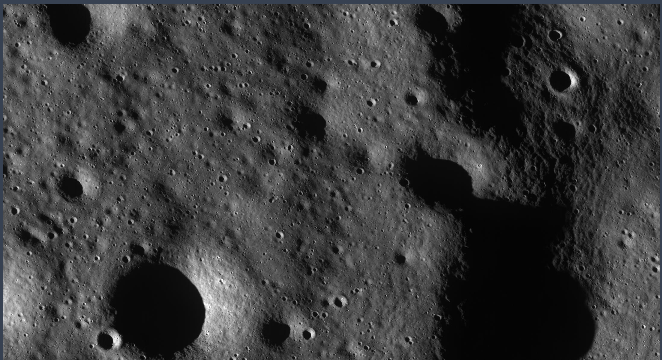

In [69]:
cv2_imshow(img)

In [70]:
def apply_contrast_stretching(image, min_val=0, max_val=255, scale_factor=1.0):
   # Convert to grayscale if necessary
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    # Find minimum and maximum pixel values
    original_min = np.min(gray)
    original_max = np.max(gray)

    # Calculate the scaling factor
    scale = (max_val - min_val) / (original_max - original_min)

    # Apply histogram stretching with optional adjustment for dark spots
    stretched = (gray - original_min) * scale
    stretched = np.uint8(stretched)

    # Adjust for dark spots (optional)
    if scale_factor > 0:
        stretched = stretched + scale_factor * (gray - original_min)

    return stretched

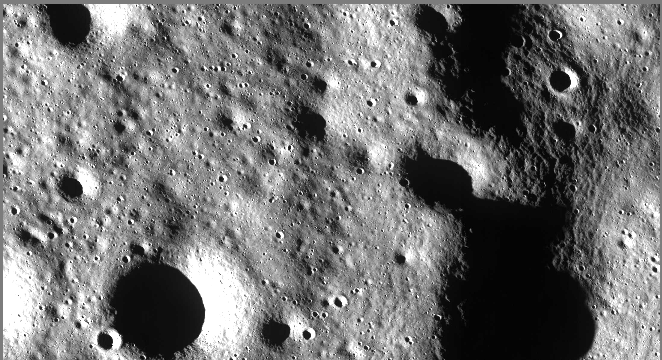

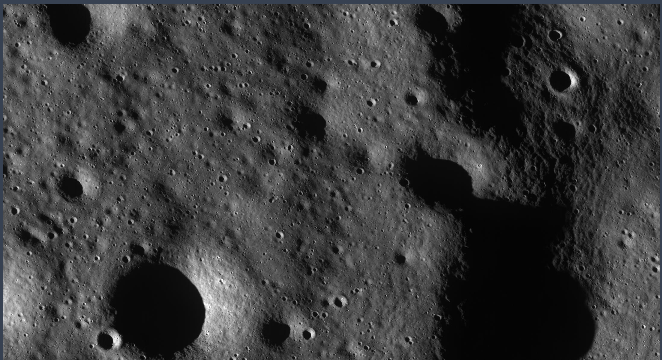

In [71]:
cv2_imshow(apply_contrast_stretching(img))
cv2_imshow(img)

In [72]:
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

array([[ 86,  86,  86, ...,  73,  73,  73],
       [ 86,  86,  86, ...,  73,  73,  73],
       [ 86,  86,  86, ...,  73,  73,  73],
       ...,
       [ 58,  58,  58, ..., 175,  55,  51],
       [ 58,  58,  58, ..., 184,  55,  51],
       [ 58,  58,  58, ..., 197,  55,  51]], dtype=uint8)
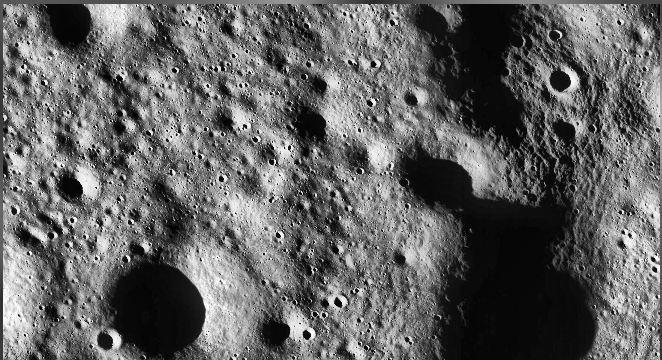

In [73]:
ahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
clahe = ahe.apply(gray_img)
clahe

In [74]:
clahe = ahe.apply(clahe)

In [75]:
denoised = cv.fastNlMeansDenoising(clahe, None, 10, 7, 21)

array([[114, 114, 114, ...,  57,  57,  57],
       [114, 114, 114, ...,  57,  57,  57],
       [114, 114, 114, ...,  56,  57,  57],
       ...,
       [ 49,  49,  49, ..., 214,  43,  37],
       [ 49,  49,  49, ..., 225,  43,  37],
       [ 49,  49,  49, ..., 238,  43,  37]], dtype=uint8)
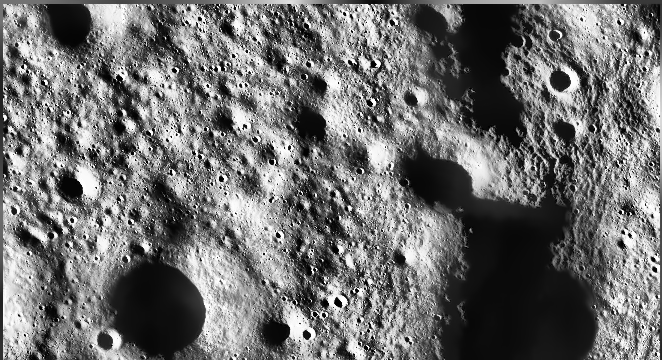

In [76]:
denoised

array([[[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55]],

       ...,

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [108, 108, 108],
        [ 82,  66,  56],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [111, 111, 111],
        [ 82,  66,  56],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [116, 116, 116],
        [ 82,  66,  56],
        [ 81,  65,  55]]], dtype=uint8)
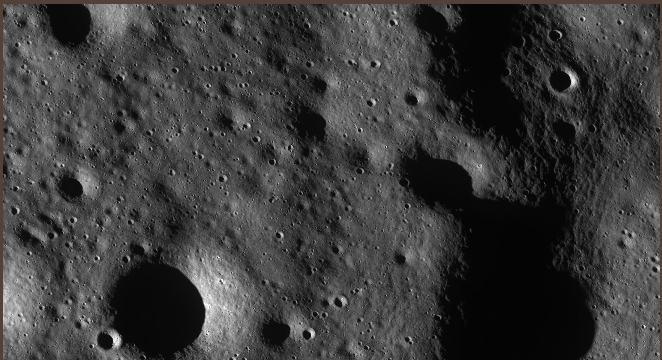

In [77]:
img

array([[ 50,  50,  50, ..., 249, 249, 249],
       [ 50,  50,  50, ..., 249, 249, 249],
       [ 50,  50,  50, ..., 248, 249, 249],
       ...,
       [241, 241, 241, ..., 106, 234, 229],
       [241, 241, 241, ..., 114, 234, 229],
       [241, 241, 241, ..., 122, 234, 229]], dtype=uint8)
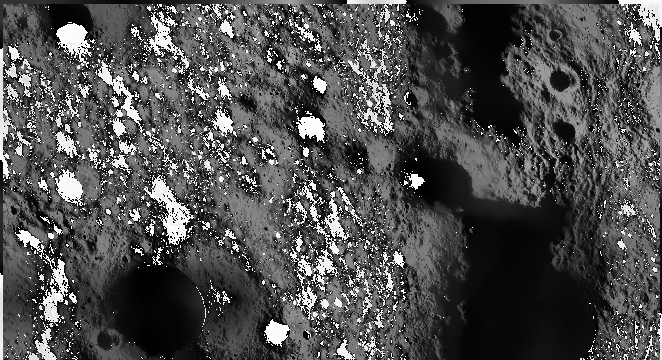

In [78]:
denoised - gray_img

array([[178, 178, 178, ..., 121, 121, 121],
       [178, 178, 178, ..., 121, 121, 121],
       [178, 178, 178, ..., 120, 121, 121],
       ...,
       [113, 113, 113, ...,  66, 108, 101],
       [113, 113, 113, ...,  80, 108, 101],
       [113, 113, 113, ...,  98, 108, 101]], dtype=uint8)
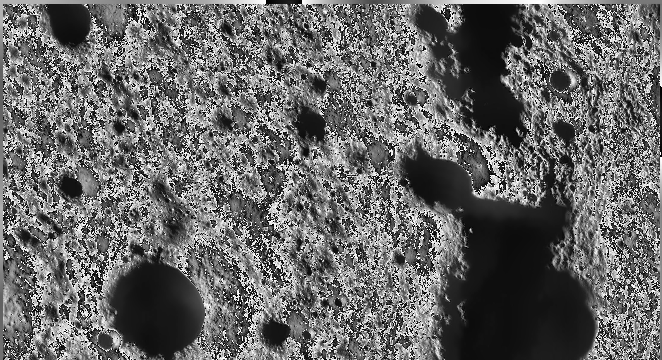

In [79]:
gray_img + denoised

In [80]:
def apply_single_scale_retinex(image, kernel_size = 125):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = gray.astype(np.float32) / 255

    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)

    illumination = cv.filter2D(gray, -1, kernel)
    retinex = np.log10(gray) - np.log10(illumination)

    # Normalize the image
    min_val = np.min(retinex)
    max_val = np.max(retinex)
    retinex = (retinex - min_val) / (max_val - min_val) * 255

    return retinex.astype(np.uint8)

In [81]:
ret = apply_single_scale_retinex(img)

In [82]:
def apply_contrast_stretching2(image, min_val=0, max_val=255, scale_factor=1.0):
   # Convert to grayscale if necessary
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    # Find minimum and maximum pixel values
    original_min = np.min(gray)
    original_max = np.max(gray)

    # Calculate the scaling factor
    scale = (original_max - original_min)/(max_val - min_val)

    # Apply histogram stretching with optional adjustment for dark spots
    stretched = (gray - original_min) * scale
    stretched = np.uint8(stretched)

    # Adjust for dark spots (optional)
    if scale_factor > 0:
        stretched = stretched + scale_factor * (gray - original_min)

    return stretched

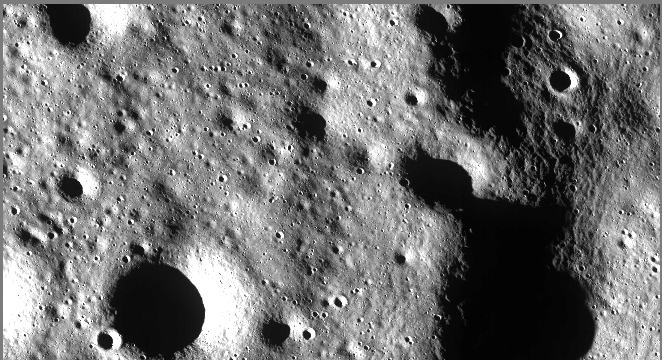

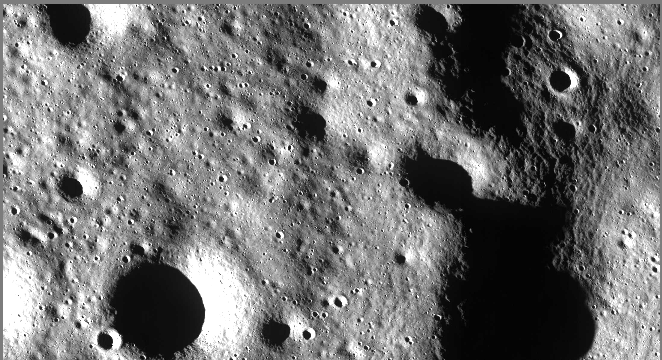

In [83]:
cv2_imshow(apply_contrast_stretching2(img))
cv2_imshow(apply_contrast_stretching(img))

In [84]:
def scale_pixel(image, lower_threshold, upper_threshold):
  gray=image

  # Thresholding to isolate pixels within the desired range

  mask = cv.inRange(gray, lower_threshold, upper_threshold)

  # Scale the pixel values within the mask
  scaled_image = gray.copy()
  scaled_image[mask > 0] = scaled_image[mask > 0] + 150  # Adjust the scaling factor as needed
  return scaled_image

In [85]:
gray_hist = cv.calcHist([gray_img], #list of images, more than one can be passed
                        [0],#No. of channels we want to calculate for
                        None,#mask (if provided, calculates histogram for a portion only)
                        [256], # no. of bins, also a list
                        [0,256]) # range of all possible pixel values, also a list

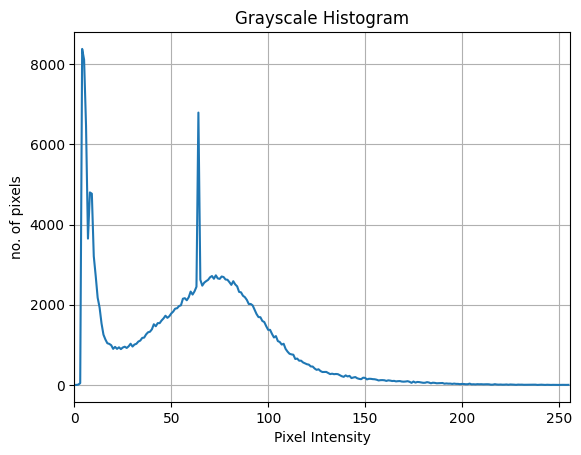

In [86]:
import matplotlib.pyplot as plt

plt.figure()
plt.title('Grayscale Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('no. of pixels')
plt.plot(gray_hist)
plt.xlim([0, 256])
plt.grid(True)
plt.show()

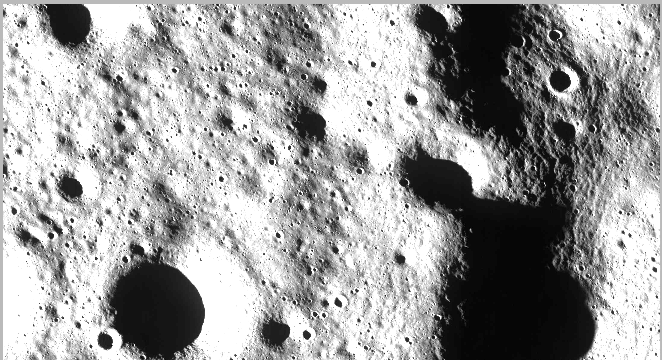

In [87]:
stretched_img = apply_contrast_stretching(img, scale_factor=2.0)
cv2_imshow(stretched_img)

array([[[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55]],

       ...,

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [108, 108, 108],
        [ 82,  66,  56],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [111, 111, 111],
        [ 82,  66,  56],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [116, 116, 116],
        [ 82,  66,  56],
        [ 81,  65,  55]]], dtype=uint8)
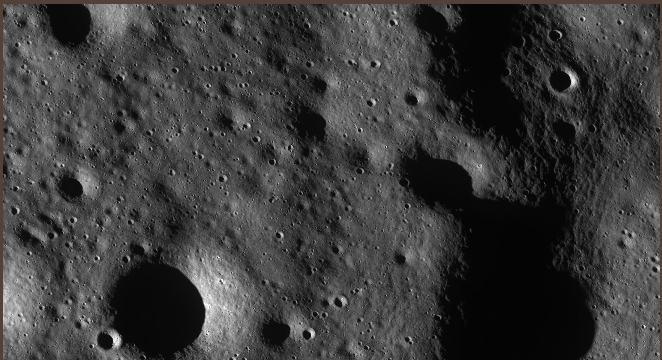

In [88]:
img

In [89]:
def enhance_dark_regions(image):
    # Convert to grayscale if necessary
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    # Apply histogram stretching
    stretched = stretched_img

    stretched = cv.convertScaleAbs(stretched)
    # Apply Canny edge detection with adjusted thresholds
    edges = cv.Canny(stretched, 50, 150)

    # Apply morphological operations to fill in gaps
    kernel = np.ones((3, 3), np.uint8)
    filled_edges = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel)

    # Combine original image with enhanced edges
    enhanced = cv.bitwise_or(image, cv.cvtColor(filled_edges, cv.COLOR_GRAY2BGR))

    return enhanced

array([[[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55],
        ...,
        [ 81,  65,  55],
        [ 81,  65,  55],
        [ 81,  65,  55]],

       ...,

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [255, 255, 255],
        ...,
        [108, 108, 108],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [255, 255, 255],
        ...,
        [111, 111, 111],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 81,  65,  55],
        [ 81,  65,  55],
        [255, 255, 255],
        ...,
        [116, 116, 116],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
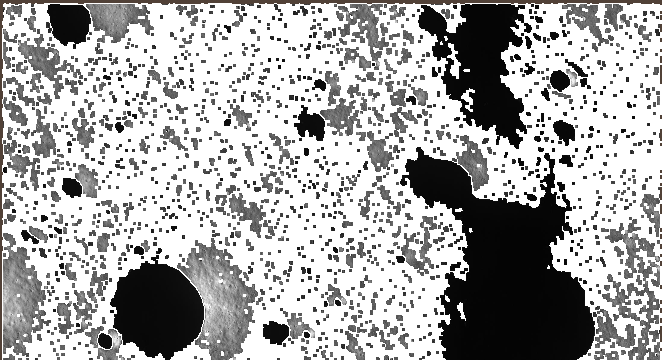

In [90]:
enhance_dark_regions(img)

In [91]:
mask =(enhance_dark_regions(img))

In [92]:
def apply_single_scale_retinex(image, kernel_size=125):
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)
    illumination = cv.filter2D(image, -1, kernel)
    retinex = np.log10(image) - np.log10(illumination)

    # Normalize the image
    min_val = np.min(retinex)
    max_val = np.max(retinex)
    retinex = (retinex - min_val) / (max_val - min_val) * 255

    return retinex.astype(np.uint8)


retinex_image = apply_single_scale_retinex(stretched_img)



<ipython-input-92-21041e882e56>:4: RuntimeWarning: divide by zero encountered in log10
  retinex = np.log10(image) - np.log10(illumination)
<ipython-input-92-21041e882e56>:9: RuntimeWarning: invalid value encountered in subtract
  retinex = (retinex - min_val) / (max_val - min_val) * 255
<ipython-input-92-21041e882e56>:9: RuntimeWarning: invalid value encountered in divide
  retinex = (retinex - min_val) / (max_val - min_val) * 255
<ipython-input-92-21041e882e56>:11: RuntimeWarning: invalid value encountered in cast
  return retinex.astype(np.uint8)


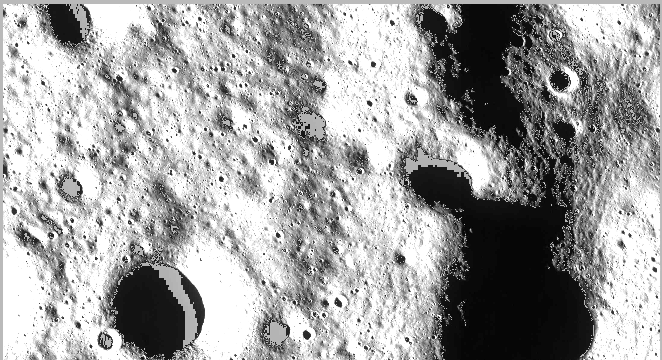

In [93]:
cv2_imshow(scale_pixel(stretched_img,25,35 ))

In [94]:
def apply_contrast_stretching(image, min_val=0, max_val=255, scale_factor=1.0):
   # Convert to grayscale if necessary
    gray = image

    # Find minimum and maximum pixel values
    original_min = np.min(gray)
    original_max = np.max(gray)

    # Calculate the scaling factor
    scale = (original_max - original_min)/(max_val - min_val)

    # Apply histogram stretching with optional adjustment for dark spots
    stretched = (gray - original_min) * scale
    stretched = np.uint8(stretched)

    # Adjust for dark spots (optional)
    if scale_factor > 0:
        stretched = stretched + scale_factor * (gray - original_min)

    return stretched

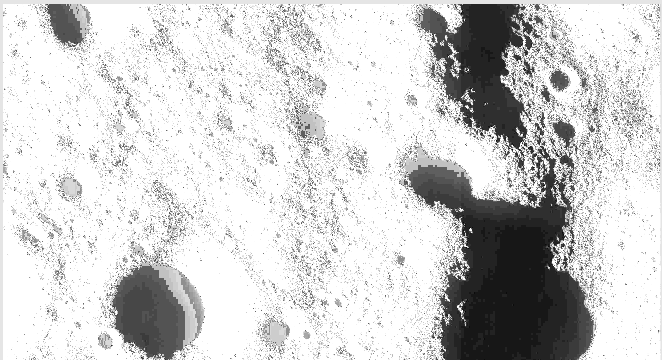

In [95]:
cv2_imshow(apply_contrast_stretching(scale_pixel(stretched_img,25,35 )))

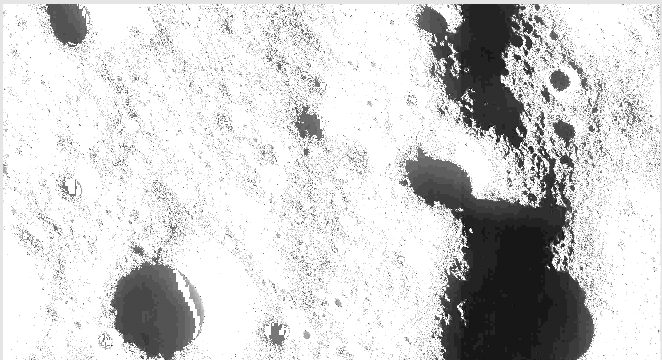

In [97]:
cv2_imshow(scale_pixel(apply_contrast_stretching(stretched_img),125, 150))

In [105]:
img2 = scale_pixel(apply_contrast_stretching(stretched_img),125, 150)

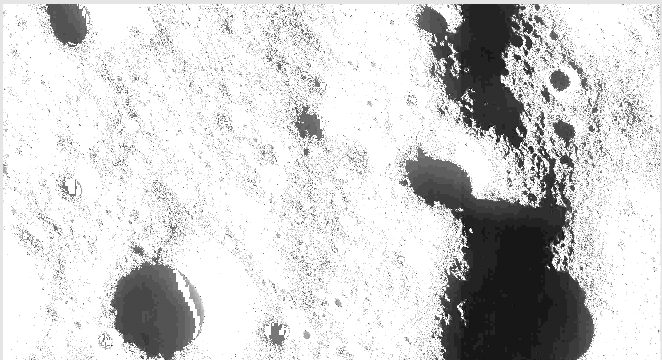

In [113]:
cv2_imshow(img2)

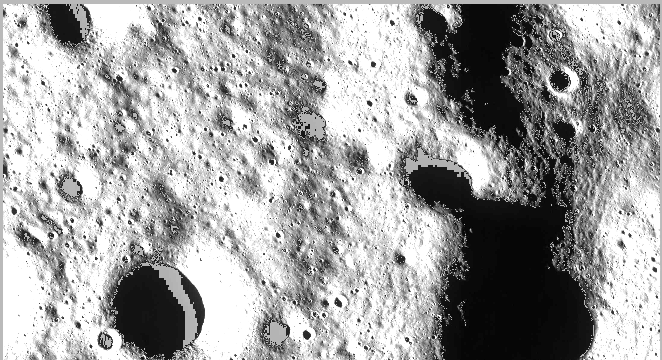

In [115]:
 img3 = scale_pixel(stretched_img,25,35 )
 cv2_imshow(img3)

In [118]:
def scale_pixel(image, lower_threshold, upper_threshold, value=100):
  gray=image

  # Thresholding to isolate pixels within the desired range

  mask = cv.inRange(gray, lower_threshold, upper_threshold)

  # Scale the pixel values within the mask
  scaled_image = gray.copy()
  scaled_image[mask > 0] = scaled_image[mask > 0] + value  # Adjust the scaling factor as needed
  return scaled_image

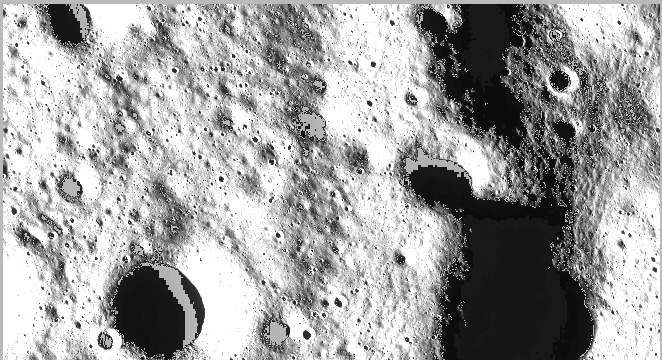

In [121]:
cv2_imshow(scale_pixel(img3, 0,10,15))

In [122]:
def down_scale_pixel(image, lower_threshold, upper_threshold, value=100):
  gray=image

  # Thresholding to isolate pixels within the desired range

  mask = cv.inRange(gray, lower_threshold, upper_threshold)

  # Scale the pixel values within the mask
  scaled_image = gray.copy()
  scaled_image[mask > 0] = scaled_image[mask > 0] - value  # Adjust the scaling factor as needed
  return scaled_image

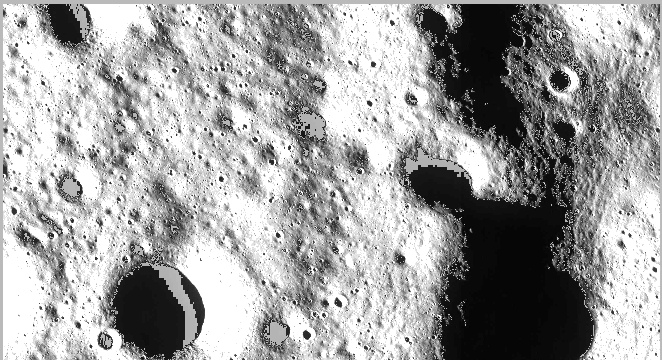

In [124]:
cv2_imshow(down_scale_pixel(img3, 235,250,15))